# Google Reviews Word Cloud Analysis

Analyze positive and negative reviews using word clouds.

In [1]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

df = pd.read_csv('data/google_reviews_en.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   userName       500 non-null    str  
 1   at             500 non-null    str  
 2   content        500 non-null    str  
 3   score          500 non-null    int64
 4   thumbsUpCount  500 non-null    int64
dtypes: int64(2), str(3)
memory usage: 19.7 KB


## Data Preparation

In [2]:
df_hi = df[df['score']>=4]
df_lo = df[df['score']<4]

list_reviews_lo = df_lo['content'].astype(str).str.lower()
list_reviews_hi = df_hi['content'].astype(str).str.lower()

reviews_lo = ' '.join(list_reviews_lo)
reviews_hi = ' '.join(list_reviews_hi)

## Word Cloud: Negative Reviews (< 4 stars)

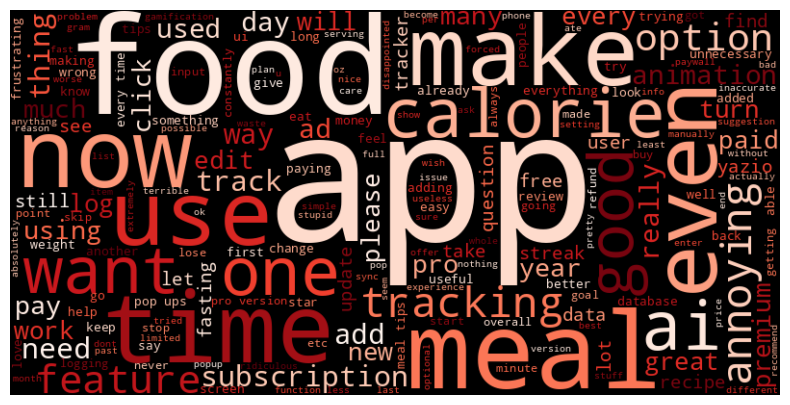

In [3]:
wordcloud_lo = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(reviews_lo)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud_lo, interpolation='bilinear')
plt.axis('off')
plt.show()
wordcloud_lo.to_file('outputs/wordcloud_lo_en.png')

There is high frequency of words like:
- ads
- subscription
- paywall

## Word Cloud: Positive Reviews (4+ stars)

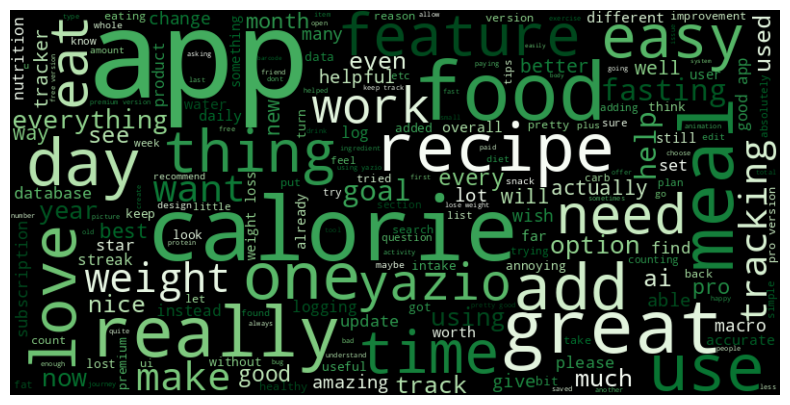

In [4]:
wordcloud_hi = WordCloud(
    width=800, height=400, background_color='black', colormap='Greens'
    ).generate(reviews_hi)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud_hi, interpolation='bilinear')
plt.axis('off')
plt.show()
wordcloud_hi.to_file('outputs/wordcloud_hi_en.png')

High Frequency:
- calorie
- tracking
- food
- easy
- feature
- goal

## Top Relevant Negative Reviews

In [5]:
import textwrap

df_lo = df_lo.sort_values(by='thumbsUpCount', ascending=False)
most_relevant_negative_reviews = df_lo['content'].head(10).tolist()

def show_reviews(reviews:list):
    for i in range(len(reviews)):
        wrapped = textwrap.fill(f'review {i+1}: {reviews[i]}', width=100)
        print(wrapped)
        print()

show_reviews(most_relevant_negative_reviews)

review 1: If you respect your time, your sanity, and want to actually track you calories with ease
and keep track of your fasting period. DO NOT GET THIS APP. People rave about how there aren't any
intrusive ads, but they fail to mention nearly everything is locked until you spend money. I
apologize but a fasting tracker is literally just a timer that's connected to a graph and you want
me to pay you for that? Spend some time browsing some older apps that do these functions, but
haven't doesn't want $$$.

review 2: My previous review was 4 star, but I downgraded it because of recent changes. It used to
be so convenient to open app, log meal, close app. Now you have to filter through multiple screens
to get to where you can log meals... and I'm a Premium Member! Sorry Yazio, but I pay for
convenience, and this app no longer qualifies. So long, and thanks for all the fish. I'm out of
here.

review 3: It's a good app, the only one I've seen that lets you select your country to give you fo

### Notes:
- Replace with app-specific findings after reviewing the printed negative reviews.

## Top Relevant Positive Reviews

In [6]:
df_hi = df_hi.sort_values(by='thumbsUpCount', ascending=False)
most_relevant_positive_reviews = df_hi['content'].head(10).tolist()

show_reviews(most_relevant_positive_reviews)

review 1: I'm on a 536 day streak and within the top 1% of users. I lost 30 kg with this app. And I
would love some more customisation options instead of new colours and an (admittedly cute) mascot.
People have been asking for adding extra meals to a day for ages and as someone who likes to eat
everything in moderation, I hate that the "food warnings" aren't optional. I don't care if my food
is "processed" that doesn't instantly mean it's bad for you, so stop with the shaming please.

review 2: I really appreciate your hard work in this one, it's worth the try and has everything
almost everything that would help you out throughout your journey. Only if you could, the fasting
feature might need a little readjustment, if it is possible to add a manual fasting tracker, where
you can choose your own time, would be better for those who have different fasting hours. So far,
the app is great!

review 3: the best calorie tracking app I've tried, the premium price is great compared to other
app

### Notes:
- Replace with app-specific findings after reviewing the printed positive reviews.


# Arabic Reviews Word Cloud Analysis

In [7]:
import arabic_reshaper
from bidi.algorithm import get_display

df_arabic = pd.read_csv('data/google_reviews_ar.csv')
df_arabic['content_reshaped'] = df_arabic['content'].apply(
    lambda x: arabic_reshaper.reshape(str(x))
)

df_ar_lo = df_arabic[df_arabic['score']<4]
df_ar_hi = df_arabic[df_arabic['score']>=4]

## Arabic Word Cloud: Negative Reviews (< 4 stars)

In [8]:
def process_arabic(text):
    reshaped = arabic_reshaper.reshape(str(text))
    return reshaped

list_reviews_lo_ar = df_ar_lo['content'].apply(process_arabic)
list_reviews_hi_ar = df_ar_hi['content'].apply(process_arabic)

reviews_lo_ar = ' '.join(list_reviews_lo_ar)
reviews_hi_ar = ' '.join(list_reviews_hi_ar)

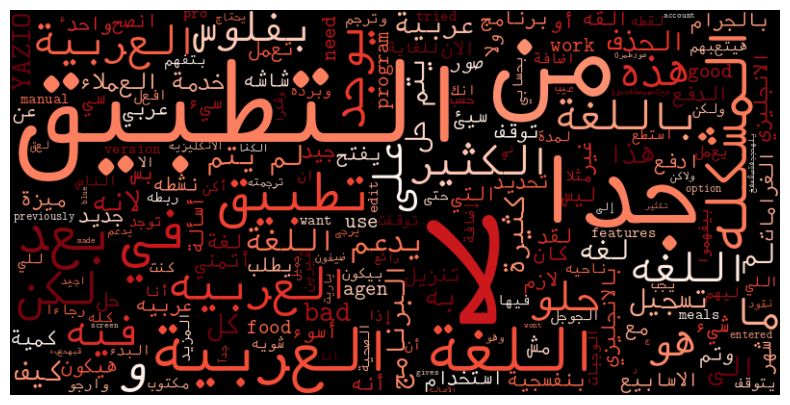

In [9]:
wordcloud_lo_ar = WordCloud(
    font_path='/usr/share/fonts/almfixed/almfixed.otf',
    width=800, 
    height=400, 
    background_color='black', 
    colormap='Reds',
).generate(reviews_lo_ar)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_lo_ar, interpolation='bilinear')
plt.axis('off')
plt.show()

wordcloud_lo_ar.to_file('outputs/wordcloud_lo_ar.png')

High Frequency:
- اللغة العربية
- لا يدعم
- التطبيق
- تسجيل
- دفع
- مشكلة

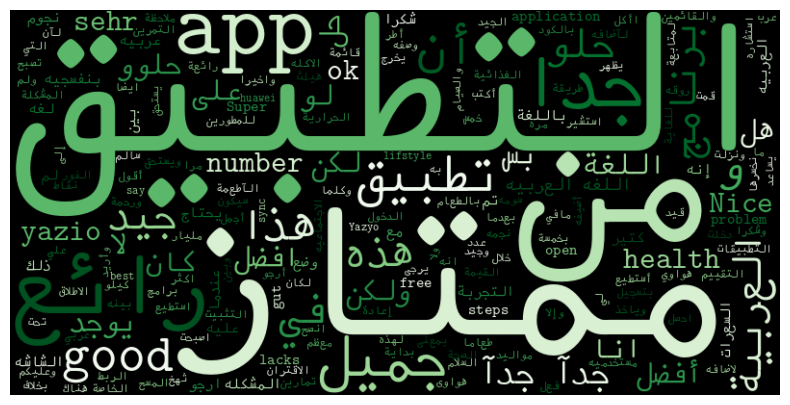

In [10]:
wordcloud_hi_ar = WordCloud(
    font_path='/usr/share/fonts/almfixed/almfixed.otf',
    width=800, 
    height=400, 
    background_color='black', 
    colormap='Greens',
).generate(reviews_hi_ar)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_hi_ar, interpolation='bilinear')
plt.axis('off')
plt.show()

wordcloud_hi_ar.to_file('outputs/wordcloud_hi_ar.png')

## Top Relevant Positive Arabic Reviews

In [11]:
df_ar_hi = df_ar_hi.sort_values(by='thumbsUpCount', ascending=False)
most_relevant_positive_reviews_ar = df_ar_hi['content'].head(10).tolist()

show_reviews(most_relevant_positive_reviews_ar)

review 1: تطبيق رائع وجيّد جدّاً .. إنهُ يستحق التقييم بخمسة نجوم 🔥 لكن هناك ملاحظة : لم يظهر لي
طعاماً ما من خلال المسح بالكود ، وأريدُ أن أضيفه إلى قائمة الأطعمة لكن عندما أكتب القيمة الغذائية
الخاصة بالطعام ، يخرج على الفور من التطبيق ولا أستطيع فعل ذلك. أرجو حل هذه المشكلة وإلا بخلاف ذلك
التطبيق ممتاز . شكراً للمطورين والقائمين عليه 😍

review 2: التطبيق رائع و جيد ولكن يحتاج لاضافه استشاره بمعنى أن استشير التطبيق هل من الجيد أن اأكل
هذه الاكله و ايضا انا مواليد 2012 و أطر لإضافه 2010 و أن يوجد في التطبيق لغه عربيه لأن معظم مستخدميه
عرب واخيرا يرجى وضع تمارين مع وضع عدد السعرات التي نخسرها في هذه التمرين و مع حل هذه المشكله سيكون
هذا افضل تطبيق وياخذ مليار نجمه @Yazyo

review 3: التطبيق ممتاز جدا وفيه أسماء لاكلات متوقعتش تكون موجودة ينقصه بس اللغه العربيه

review 4: بعدما تم إعادة الاقتران بين التطبيق وبين تطبيق الصحة من هواوى استطيع أن أقول إنه أفضل
تطبيق على الاطلاق لمتابعة السعرات الحرارية والصيام. After sync between huawei health and yazio i can
say yazio is the best app for li

## Top Relevant Negative Arabic Reviews

In [12]:
df_ar_lo = df_ar_lo.sort_values(by='thumbsUpCount', ascending=False)
most_relevant_negative_reviews_ar = df_ar_lo['content'].head(10).tolist()

show_reviews(most_relevant_negative_reviews_ar)

review 1: لا احد يحمل هذا البرنامج لانه بيطلب دفع مقابل مادى ولا يوجد رابط واحد شغال ادفع تاخد
المعلومة فضلا عن انه لا يدعم اللغة العربية جاري الخذف

review 2: برنامج رائع ولاكن انا لا اجيد اللغه الانكليزيه ياريت ضيفون اللغه العربيه

review 3: التطبيق جيد جداً لكن لا يوجد ميزة توقف إذا توقفت لمدة شهر مثلاً يجب أن يتوقف حسب الاسابيع
التي كنت نشطه به حتى أنا ميزة البدء من جديد لا تعمل الاسابيع التي لم أكن نشطه فيها كثيرة للغاية
وارجو اضافة اللغة العربية

review 4: سأقوم بحذف البرنامج لأن لا يعترف باللغة العربية

review 5: سي جدا لا يدعم العربيه

review 6: لايدعم لغتي العربية،وتم الحذف

review 7: كيف بيشتغل على اللغة العربية

review 8: حلو بس لازم اللغه العربيه

review 9: كيف يعمل التطبيق باللغة العربيه رجاءا كيف افعل اللغة العربية

review 10: التطبيق بعد ما سجلت فيه ودخلت الايمل مش راضي يفتح

